<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/rabiresonance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qutip


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 55.2 MB/s eta 0:00:00


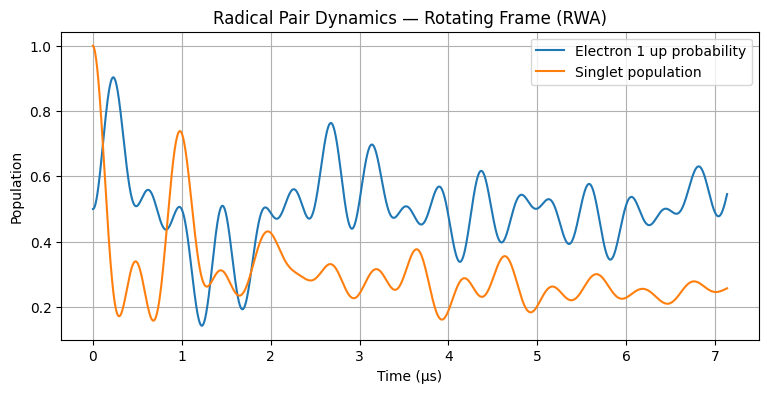

In [ ]:
# Rotating-frame + RWA version (cleaned)
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ----------------- constants & helper -----------------
γ0 = 2*np.pi*28.024e9   # rad s^-1 T^-1 (electron gyromagnetic ratio ~ 2π·28.024 GHz/T)

sx = sigmax()/2; sy = sigmay()/2; sz = sigmaz()/2
Id2 = qeye(2)

def make_tensor_operator(single_ops, total_subsystems):
    ops = []
    for i in range(total_subsystems):
        ops.append(single_ops.get(i, Id2))
    return tensor(ops)

# ----------------- system config (from your script) -----------------
nuclei_r1 = 1
nuclei_r2 = 1
Nsubs = 2 + nuclei_r1 + nuclei_r2

g1 = np.array([2.003, 2.003, 2.003])
g2 = np.array([2.003, 2.003, 2.003])

B0 = np.array([0.0, 0.0, 50e-6])      # T
B1 = np.array([50e-6, 0.0, 0.0])     # T (drive along x)

# resonant drive frequency chosen as Zeeman of electron1 (rad/s)
omega_drive = γ0 * (g1[2]/2.0) * B0[2]

# hyperfine tensors (rad/s)
A_r1 = [ np.eye(3) * (2*np.pi*2.0e6) ]
A_r2 = [ np.eye(3) * (2*np.pi*0.8e6) ]

J = 0.0   # exchange (rad/s)

# decoherence (phenomenological)
T1 = 50e-6
T2 = 2e-6
gamma1 = 1.0 / T1
gamma2 = 1.0 / T2

# ----------------- Build operators -----------------
S1x = make_tensor_operator({0: sx}, Nsubs)
S1y = make_tensor_operator({0: sy}, Nsubs)
S1z = make_tensor_operator({0: sz}, Nsubs)

S2x = make_tensor_operator({1: sx}, Nsubs)
S2y = make_tensor_operator({1: sy}, Nsubs)
S2z = make_tensor_operator({1: sz}, Nsubs)

Iops_r1 = []
for i in range(nuclei_r1):
    idx = 2 + i
    Iops_r1.append(( make_tensor_operator({idx: sx}, Nsubs),
                     make_tensor_operator({idx: sy}, Nsubs),
                     make_tensor_operator({idx: sz}, Nsubs) ))

Iops_r2 = []
for j in range(nuclei_r2):
    idx = 2 + nuclei_r1 + j
    Iops_r2.append(( make_tensor_operator({idx: sx}, Nsubs),
                     make_tensor_operator({idx: sy}, Nsubs),
                     make_tensor_operator({idx: sz}, Nsubs) ))

# ----------------- static Hamiltonian H0 -----------------
HZ1 = (γ0 * (g1[0]/2.0) * B0[0]) * S1x + (γ0 * (g1[1]/2.0) * B0[1]) * S1y + (γ0 * (g1[2]/2.0) * B0[2]) * S1z
HZ2 = (γ0 * (g2[0]/2.0) * B0[0]) * S2x + (γ0 * (g2[1]/2.0) * B0[1]) * S2y + (γ0 * (g2[2]/2.0) * B0[2]) * S2z

Hhf = 0
for k, A in enumerate(A_r1):
    Ix, Iy, Iz = Iops_r1[k]
    Hhf += S1x*(A[0,0]*Ix + A[0,1]*Iy + A[0,2]*Iz)
    Hhf += S1y*(A[1,0]*Ix + A[1,1]*Iy + A[1,2]*Iz)
    Hhf += S1z*(A[2,0]*Ix + A[2,1]*Iy + A[2,2]*Iz)

for k, A in enumerate(A_r2):
    Ix, Iy, Iz = Iops_r2[k]
    Hhf += S2x*(A[0,0]*Ix + A[0,1]*Iy + A[0,2]*Iz)
    Hhf += S2y*(A[1,0]*Ix + A[1,1]*Iy + A[1,2]*Iz)
    Hhf += S2z*(A[2,0]*Ix + A[2,1]*Iy + A[2,2]*Iz)

Hex = 2.0 * J * (S1x*S2x + S1y*S2y + S1z*S2z)

H0 = HZ1 + HZ2 + Hhf + Hex

# ----------------- Rotating frame (RWA) -----------------
# Transform generator: subtract omega_drive * (S1z + S2z)
H_rot = H0 - omega_drive * (S1z + S2z)

# Build Dop_x operator (γ0*(g/2) * Sx terms)
Dop_x = (γ0*(g1[0]/2.0)*S1x + γ0*(g2[0]/2.0)*S2x)

# Under RWA: cos(ωt) -> factor 1/2; drive term becomes (B1_x/2) * Dop_x (time-independent)
Hdrive_rot_const = 0.5 * B1[0] * Dop_x

H = H_rot + Hdrive_rot_const

# ----------------- collapse operators -----------------
c_ops = [ np.sqrt(gamma2) * S1z, np.sqrt(gamma2) * S2z ]
# (add relaxation sm1/sm2 if needed)

# ----------------- initial state and observables -----------------
up = basis(2,0); down = basis(2,1)
singlet_el = (tensor(up, down) - tensor(down, up)).unit()

nuc_state = tensor([up for _ in range(nuclei_r1 + nuclei_r2)])
psi0 = tensor(singlet_el, nuc_state)

Proj_up_1 = make_tensor_operator({0: up*up.dag()}, Nsubs)

# singlet projector on electrons tensored with nuclear identity
P_s_el = singlet_el * singlet_el.dag()
I_nuc = tensor([qeye(2) for _ in range(nuclei_r1 + nuclei_r2)])
P_singlet = tensor(P_s_el, I_nuc)

# ----------------- time grid (before mesolve) -----------------
# Estimate Rabi frequency scale in rad/s (rough): Ω ≈ γ0 * ||B1||
Omega_R_est = γ0 * np.linalg.norm(B1)
if Omega_R_est == 0:
    Omega_R_est = 1.0
T_R = 2*np.pi / Omega_R_est
tlist = np.linspace(0, 10*T_R, 2000)   # simulate ~10 Rabi periods

# ----------------- run solver -----------------
result = mesolve(H, psi0, tlist, c_ops, e_ops=[Proj_up_1, P_singlet])
P_up = result.expect[0]
P_s = np.real(result.expect[1])

# ----------------- plotting -----------------
plt.figure(figsize=(9,4))
plt.plot(tlist*1e6, P_up, label='Electron 1 up probability')
plt.plot(tlist*1e6, P_s, label='Singlet population')
plt.xlabel("Time (µs)")
plt.ylabel("Population")
plt.title("Radical Pair Dynamics — Rotating Frame (RWA)")
plt.legend()
plt.grid(True)
plt.show()


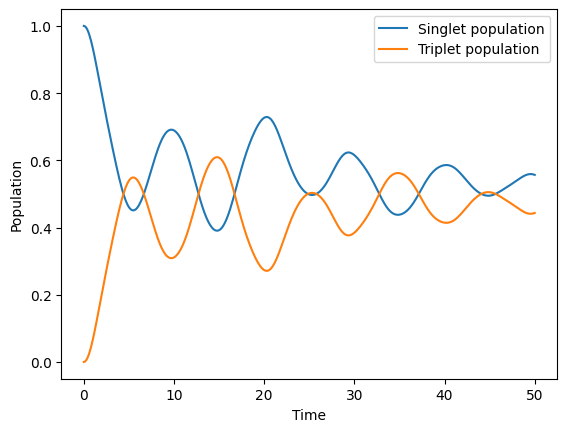

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# --- PARAMETERS ---
mu_B = 2.0       # Bohr magneton (arb. units)
B = 1.0          # Magnetic field magnitude (along z)
g1, g2 = 0.4, 0.4  # Electron g-factors
J = 0.05         # Exchange coupling constant
A1 = [0.1, 0.1, 0.2]  # Hyperfine for nucleus 1
A2 = [0.05, 0.05, 0.1]  # Hyperfine for nucleus 2
k_S = 0.1        # Singlet recombination rate

# --- DEFINE SPIN OPERATORS ---
# Hilbert space order: electron1, electron2, nucleus1, nucleus2

sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sy_e1 = tensor(sigmay(), qeye(2), qeye(2), qeye(2))
sz_e1 = tensor(sigmaz(), qeye(2), qeye(2), qeye(2))

sx_e2 = tensor(qeye(2), sigmax(), qeye(2), qeye(2))
sy_e2 = tensor(qeye(2), sigmay(), qeye(2), qeye(2))
sz_e2 = tensor(qeye(2), sigmaz(), qeye(2), qeye(2))

sx_n1 = tensor(qeye(2), qeye(2), sigmax(), qeye(2))
sy_n1 = tensor(qeye(2), qeye(2), sigmay(), qeye(2))
sz_n1 = tensor(qeye(2), qeye(2), sigmaz(), qeye(2))

sx_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmax())
sy_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmay())
sz_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmaz())

# --- HAMILTONIAN ---

B_vec = np.array([0, 0, B])  # magnetic field along z

H_Z = mu_B * (
    g1 * (B_vec[0]*sx_e1 + B_vec[1]*sy_e1 + B_vec[2]*sz_e1) +
    g2 * (B_vec[0]*sx_e2 + B_vec[1]*sy_e2 + B_vec[2]*sz_e2)
)

H_HF = (
    A1[0] * sx_e1 * sx_n1 + A1[1] * sy_e1 * sy_n1 + A1[2] * sz_e1 * sz_n1 +
    A2[0] * sx_e2 * sx_n2 + A2[1] * sy_e2 * sy_n2 + A2[2] * sz_e2 * sz_n2
)

H_J = J * (sx_e1 * sx_e2 + sy_e1 * sy_e2 + sz_e1 * sz_e2)

H = H_Z + H_HF + H_J

# --- INITIAL STATE ---

# Electron singlet state |S> = (|01> - |10>)/sqrt(2)
singlet_elec = (tensor(basis(2,0), basis(2,1)) - tensor(basis(2,1), basis(2,0))).unit()

# Nuclear spins in mixed state (identity / 4)
rho_nuc = tensor(qeye(2)/2, qeye(2)/2)

# Full initial state: singlet electrons tensor nuclear mixed state
rho0 = tensor(ket2dm(singlet_elec), rho_nuc)

# --- COLLAPSE OPERATORS ---

# Singlet projector on electron spins
P_S_elec = ket2dm(singlet_elec)

# Lift singlet projector to full space by tensor nuclear identity
P_S_full = tensor(P_S_elec, qeye(2), qeye(2))

# Collapse operator for singlet recombination
c_ops = [np.sqrt(k_S) * P_S_full]

# --- OBSERVABLES ---

# Triplet projector = Identity on electrons - singlet projector
P_T_elec = tensor(qeye(2), qeye(2)) - P_S_elec
P_T_full = tensor(P_T_elec, qeye(2), qeye(2))

observables = [P_S_full, P_T_full]

# --- TIME EVOLUTION ---

tlist = np.linspace(0, 50, 500)
result = mesolve(H, rho0, tlist, c_ops,observables)

# --- PLOTTING ---

plt.plot(tlist, result.expect[0], label='Singlet population')
plt.plot(tlist, result.expect[1], label='Triplet population')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()